In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('bank.csv', sep=';')


In [44]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


In [45]:
selected_df = df[['age', 'job', 'marital', 'education', 'balance', 'housing', 'loan', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']]

selected_df

,age,job,marital,education,balance,housing,loan,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,1787,no,no,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,4789,yes,yes,may,220,1,339,4,failure,no
2,35,management,single,tertiary,1350,yes,no,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,1476,yes,yes,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,0,yes,no,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,-333,yes,no,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,-3313,yes,yes,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,295,no,no,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,1137,no,no,feb,129,4,211,3,other,no


In [46]:
null = selected_df == 'unknown'
null_in_df2 = null.sum()
print(null_in_df2)

age             0
job            38
marital         0
education     187
balance         0
housing         0
loan            0
month           0
duration        0
campaign        0
pdays           0
previous        0
poutcome     3705
y               0
dtype: int64


In [47]:
percent_of_null = null_in_df2 / len(selected_df)*  100

percent_of_null

age           0.000000
job           0.840522
marital       0.000000
education     4.136253
balance       0.000000
housing       0.000000
loan          0.000000
month         0.000000
duration      0.000000
campaign      0.000000
pdays         0.000000
previous      0.000000
poutcome     81.950896
y             0.000000
dtype: float64

In [48]:
selected_df = selected_df[selected_df['job'] != 'unknown']
selected_df = selected_df[selected_df['education'] != 'unknown']

null = selected_df == 'unknown'
null_in_df2 = null.sum()
print(null_in_df2)

age             0
job             0
marital         0
education       0
balance         0
housing         0
loan            0
month           0
duration        0
campaign        0
pdays           0
previous        0
poutcome     3536
y               0
dtype: int64


In [49]:
selected_df_duplicated = selected_df.duplicated().sum()

selected_df_duplicated

np.int64(0)

38
0.8405220084052201
age
506
11.19221411192214
balance
330
7.2992700729927
duration
318
7.033842070338421
campaign
816
18.049104180491042
pdays
816
18.049104180491042
previous


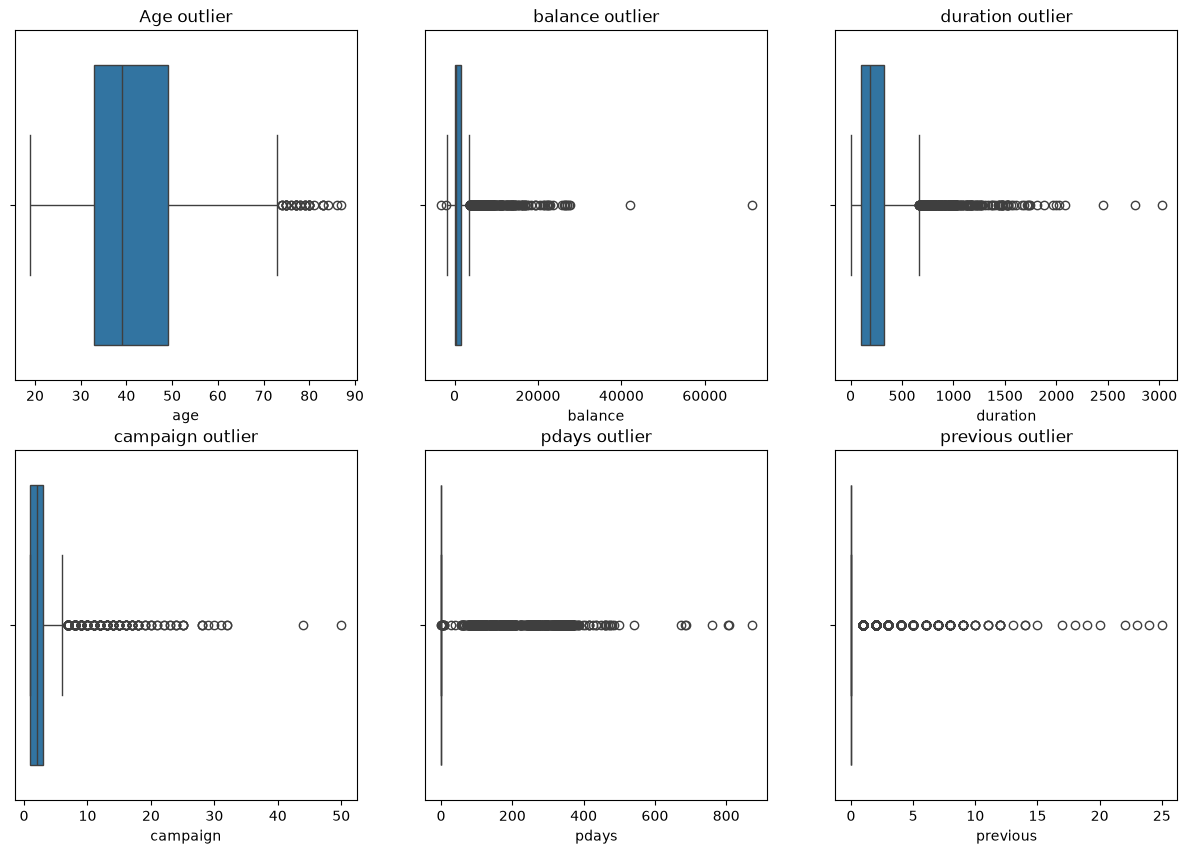

In [50]:
# tesk 12
number_vlue =['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
fig, axes = plt.subplots(2, 3 , figsize=(15, 10))

sns.boxplot(x='age', data=df, ax=axes[0,0])
axes[0,0].set_title('Age outlier')

sns.boxplot(x='balance', data=df, ax=axes[0,1])
axes[0,1].set_title('balance outlier')

sns.boxplot(x='duration', data=df, ax=axes[0,2])
axes[0,2].set_title('duration outlier')

sns.boxplot(x='campaign', data=df, ax=axes[1,0])
axes[1,0].set_title('campaign outlier')

sns.boxplot(x='pdays', data=df, ax=axes[1,1])
axes[1,1].set_title('pdays outlier')

sns.boxplot(x='previous', data=df, ax=axes[1,2])
axes[1,2].set_title('previous outlier')

for vlue in number_vlue :
    Q1 = df[vlue].quantile(0.25)
    Q3 = df[vlue].quantile(0.75)
    IQR = Q3 - Q1
    lower_iqr = Q1 - 1.5 * IQR
    upper_iqr = Q3 + 1.5 * IQR
    outliers = df[(df[vlue] < lower_iqr) | (df[vlue] > upper_iqr)]
    print(len(outliers))
    print((len(outliers)/ len(df)) * 100)
    print(vlue)
    

In [51]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR
outliers = (df['age'] < lower_iqr) | (df['age'] > upper_iqr)
outlierss = df.loc[outliers, 'age'].tolist()
df.loc[outliers, 'age'] = df['age'].median()
print(len(outlierss))

38


In [52]:
def pdays_range(pdays):
    if pdays == -1:
        return "no pdays contact"
    elif pdays <= 90:
        return "recent"
    elif pdays <= 160:
        return "medium"
    elif pdays <= 360:
        return "old"
    else:
        return "very old"

selected_df['pdays'] = selected_df['pdays'].apply(pdays_range)

selected_df['pdays'].value_counts()

pdays
no pdays contact    3536
old                  451
medium               167
very old              89
recent                68
Name: count, dtype: int64

In [53]:
def previous_range(previous):
    if previous == 0:
        return "no previous contact"
    elif previous <= 2:
        return "few contacts"
    elif previous <= 5:
        return "medium contacts"
    else:
        return "many contacts"

selected_df['previous'] = selected_df['previous'].apply(previous_range)

selected_df['previous'].value_counts()

previous
no previous contact    3536
few contacts            450
medium contacts         230
many contacts            95
Name: count, dtype: int64

In [54]:
def campaign_range(campaign):
    if campaign == 0:
        return "no campaign contact"
    elif campaign <= 2:
        return "few contacts"
    elif campaign <= 5:
        return "medium contacts"
    else:
        return "many contacts"

selected_df['campaign'] = selected_df['campaign'].apply(campaign_range)

selected_df['campaign'].value_counts()

campaign
few contacts       2849
medium contacts    1013
many contacts       449
Name: count, dtype: int64

In [55]:
def total_loan(housing, loan):
    if housing == 'no' and loan == 'no':
        return "no loan"
    elif housing == 'yes' and loan == 'yes':
        return "2 loans"
    else:
        return "1 loan"

selected_df['total_loan'] = selected_df.apply(
    lambda x: total_loan(x['housing'], x['loan']),
    axis=1
)
selected_df.drop(
    columns=['housing', 'loan'],inplace=True)

selected_df['total_loan'].value_counts()


total_loan
1 loan     2352
no loan    1556
2 loans     403
Name: count, dtype: int64

In [56]:
type_data = selected_df.dtypes

type_data


age           int64
job             str
marital         str
education       str
balance       int64
month           str
duration      int64
campaign        str
pdays           str
previous        str
poutcome        str
y               str
total_loan      str
dtype: object

In [58]:
catgory_columns = selected_df[['job', 'marital', 'education', 'total_loan', 'month', 'campaign', 'pdays', 'previous', 'poutcome']]
for columns in catgory_columns:
    selected_df[columns] = selected_df[columns].astype('category')

type_data = selected_df.dtypes

type_data

age              int64
job           category
marital       category
education     category
balance          int64
month         category
duration         int64
campaign      category
pdays         category
previous      category
poutcome      category
y                  str
total_loan    category
dtype: object

In [ ]:
describe = selected_df.info()

describe

selected_df

<class 'pandas.DataFrame'>
Index: 4311 entries, 0 to 4520
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   age           4311 non-null   int64   
 1   job           4311 non-null   category
 2   marital       4311 non-null   category
 3   education     4311 non-null   category
 4   balance       4311 non-null   int64   
 5   loan          4311 non-null   category
 6   month         4311 non-null   category
 7   duration      4311 non-null   int64   
 8   campaign      4311 non-null   category
 9   pdays         4311 non-null   category
 10  previous      4311 non-null   category
 11  poutcome      4311 non-null   category
 12  Time_deposit  4311 non-null   str     
dtypes: category(9), int64(3), str(1)
memory usage: 207.0 KB


,age,job,marital,education,balance,loan,month,duration,campaign,pdays,previous,poutcome,Time_deposit
0,30,unemployed,married,primary,1787,no loan,oct,79,few contacts,no pdays contact,no previous contact,unknown,no
1,33,services,married,secondary,4789,2 loans,may,220,few contacts,old,medium contacts,failure,no
2,35,management,single,tertiary,1350,1 loan,apr,185,few contacts,old,few contacts,failure,no
3,30,management,married,tertiary,1476,2 loans,jun,199,medium contacts,no pdays contact,no previous contact,unknown,no
4,59,blue-collar,married,secondary,0,1 loan,may,226,few contacts,no pdays contact,no previous contact,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,-333,1 loan,jul,329,medium contacts,no pdays contact,no previous contact,unknown,no
4517,57,self-employed,married,tertiary,-3313,2 loans,may,153,few contacts,no pdays contact,no previous contact,unknown,no
4518,57,technician,married,secondary,295,no loan,aug,151,many contacts,no pdays contact,no previous contact,unknown,no
4519,28,blue-collar,married,secondary,1137,no loan,feb,129,medium contacts,old,medium contacts,other,no


In [61]:
save_selected_df = selected_df.to_csv('bank_preprocessed.csv')